# **Notebook 05: Anomaly Detection**
## **Production Fraud Detection Platform on AWS**

---

### **Project Context**

This notebook is part of a 6-notebook series building
a production-grade fraud detection platform on AWS.
In Notebooks 01–04 we built supervised models — we
trained XGBoost and LightGBM on labeled transactions
where we already knew which ones were fraud.

This notebook takes a fundamentally different approach:
**unsupervised anomaly detection**.

We ask the model not "is this fraud?" but rather:
**"does this transaction look abnormal?"**

---

### **Dataset: ULB Credit Card Fraud**

| Property | Value |
|---|---|
| **Source** | Université Libre de Bruxelles (ULB) |
| **Transactions** | 284,807 |
| **Fraud** | 492 (0.172%) |
| **Class imbalance** | 578:1 |
| **Features** | 28 PCA components (V1–V28) + Amount + Time |
| **Raw features** | Not available — anonymized for privacy |

The 0.172% fraud rate makes this the most extreme
class imbalance of all three datasets in this project:

| Dataset | Fraud Rate | Imbalance |
|---|---|---|
| PaySim | 7.5% | 12:1 |
| IEEE-CIS | 3.5% | 28:1 |
| **ULB** | **0.172%** | **578:1** |

---

### **Three Approaches We Compare**

| Approach | Type | Core Idea |
|---|---|---|
| **Isolation Forest** | Tree-based | Fraud isolates faster in random trees |
| **Autoencoder** | Neural Network | Fraud has higher reconstruction error |
| **One-Class SVM** | Kernel-based | Fraud falls outside the normal boundary |

All three are trained on **legitimate transactions only**.
No fraud labels are used during training.

---

### **Notebook Structure**

| Cell | Topic |
|---|---|
| Cell 1 | Environment setup + load ULB dataset |
| Cell 2 | EDA — class imbalance, distributions |
| Cell 3 | Isolation Forest |
| Cell 4 | Autoencoder (neural network) |
| Cell 5 | One-Class SVM |
| Cell 6 | Final comparison |

## **Environment Setup + Data Loading**

### What we do
Load the ULB creditcard.csv dataset from S3 and
perform a first inspection of the data. We check
the class imbalance, feature types, and basic
statistics to understand what we are working with.

### Why it matters
The ULB dataset is already PCA-transformed for
privacy — we have no raw features, only 28 anonymous
components (V1–V28) plus Amount and Time. This means
feature engineering is limited, making model selection
and anomaly scoring even more important.

In [1]:
# ============================================================
# CELL 1: Environment Setup + Load ULB Dataset
# ============================================================

import pandas as pd
import numpy as np
import boto3
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("  NOTEBOOK 05 — ANOMALY DETECTION")
print("  ULB Credit Card Fraud Dataset")
print("=" * 55)

# ── STEP 1: Check libraries ───────────────────────────────────
print("\nStep 1: Checking libraries...")

import sklearn
import matplotlib
import seaborn
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   sklearn    : {sklearn.__version__}")
print(f"   matplotlib : {matplotlib.__version__}")
print(f"   seaborn    : {seaborn.__version__}")

# ── STEP 2: Load from S3 ─────────────────────────────────────
print("\nStep 2: Loading creditcard.csv from S3...")

BUCKET = "fraud-detection-mlproject-armand"
s3     = boto3.client('s3', region_name='us-east-1')

s3.download_file(
    BUCKET,
    'raw-data/creditcard.csv',
    '/tmp/creditcard.csv'
)

size = os.path.getsize(
    '/tmp/creditcard.csv'
) / (1024 * 1024)
print(f"   Downloaded : creditcard.csv ({size:.1f} MB)")

df = pd.read_csv('/tmp/creditcard.csv')
print(f"   Shape      : {df.shape}")
print(f"   Memory     : "
      f"{df.memory_usage().sum()/1024**2:.1f} MB")

# ── STEP 3: Dataset overview ──────────────────────────────────
print("\nStep 3: Dataset overview...")

n_total    = len(df)
n_fraud    = int(df['Class'].sum())
n_legit    = n_total - n_fraud
fraud_rate = n_fraud / n_total * 100

print(f"\n   Total transactions : {n_total:,}")
print(f"   Legitimate         : {n_legit:,} "
      f"({100-fraud_rate:.3f}%)")
print(f"   Fraud              : {n_fraud:,} "
      f"({fraud_rate:.3f}%)")
print(f"\n   Class imbalance    : "
      f"{n_legit/n_fraud:.0f}:1")
print(f"   (vs IEEE-CIS       : ~28:1)")
print(f"   (vs PaySim         : ~13:1)")

# ── STEP 4: Feature overview ──────────────────────────────────
print("\nStep 4: Feature overview...")

pca_features = [c for c in df.columns
                if c.startswith('V')]
print(f"   PCA features : {len(pca_features)} "
      f"(V1-V{len(pca_features)})")
print(f"   Amount range : "
      f"${df['Amount'].min():.2f} "
      f"to ${df['Amount'].max():.2f}")
print(f"   Amount mean  : ${df['Amount'].mean():.2f}")
print(f"   Time range   : {df['Time'].max()/3600:.0f} hours")
print(f"   Missing vals : {df.isnull().sum().sum()}")

# ── STEP 5: Class imbalance summary ──────────────────────────
print(f"\n{'='*55}")
print(f"CLASS IMBALANCE COMPARISON")
print(f"{'='*55}")
print(f"\n   {'Dataset':<12} {'Fraud Rate':>11} "
      f"{'Imbalance':>11}")
print(f"   {'-'*36}")
print(f"   {'PaySim':<12} {'7.500%':>11} {'13:1':>11}")
print(f"   {'IEEE-CIS':<12} {'3.500%':>11} {'28:1':>11}")
print(f"   {'ULB':<12} {fraud_rate:>10.3f}% "
      f"{n_legit//n_fraud:>10}:1")
print(f"\n   Dataset ready! Fraud: {n_fraud:,} "
      f"out of {n_total:,} transactions")

  NOTEBOOK 05 — ANOMALY DETECTION
  ULB Credit Card Fraud Dataset

Step 1: Checking libraries...
   pandas     : 2.3.3
   numpy      : 1.26.4
   sklearn    : 1.7.2
   matplotlib : 3.10.8
   seaborn    : 0.13.2

Step 2: Loading creditcard.csv from S3...
   Downloaded : creditcard.csv (143.8 MB)
   Shape      : (284807, 31)
   Memory     : 67.4 MB

Step 3: Dataset overview...

   Total transactions : 284,807
   Legitimate         : 284,315 (99.827%)
   Fraud              : 492 (0.173%)

   Class imbalance    : 578:1
   (vs IEEE-CIS       : ~28:1)
   (vs PaySim         : ~13:1)

Step 4: Feature overview...
   PCA features : 28 (V1-V28)
   Amount range : $0.00 to $25691.16
   Amount mean  : $88.35
   Time range   : 48 hours
   Missing vals : 0

CLASS IMBALANCE COMPARISON

   Dataset       Fraud Rate   Imbalance
   ------------------------------------
   PaySim            7.500%        13:1
   IEEE-CIS          3.500%        28:1
   ULB               0.173%        577:1

   Dataset ready! F


The ULB dataset loaded successfully with no missing values
and clean structure.

| Property | Value |
|---|---|
| **Total transactions** | 284,807 |
| **Legitimate** | 284,315 (99.827%) |
| **Fraud** | 492 (0.173%) |
| **Class imbalance** | 577:1 |
| **PCA features** | 28 (V1–V28) |
| **Amount range** | $0.00 to $25,691.16 |
| **Time coverage** | 48 hours of transactions |
| **Missing values** | 0 |

### Key observation — extreme class imbalance:
At 577:1, this dataset is 20x more imbalanced than
IEEE-CIS (28:1) and 44x more imbalanced than PaySim (13:1).
A naive classifier that predicts "legitimate" for every
transaction would achieve 99.827% accuracy — completely
useless for fraud detection. This is exactly why
unsupervised anomaly detection is the right approach here:
we do not ask the model to learn fraud patterns, we ask it
to learn what "normal" looks like and flag everything else.

### Why the PCA transformation matters:
All 28 features are already anonymized PCA components.
This means we cannot engineer new domain features like
uid_fraud_rate or balance_diff — we must work with the
mathematical structure of the data as-is. This actually
favors anomaly detection algorithms like Isolation Forest
and Autoencoder, which excel at finding unusual patterns
in high-dimensional transformed spaces.

## **Exploratory Data Analysis**

### What we do
Visualise the ULB dataset to understand the distribution
of fraud vs legitimate transactions. We examine the class
imbalance visually, the Amount distribution for both
classes, the Time distribution, and the top PCA features
that best separate fraud from legitimate transactions.

### Why it matters
Before building any anomaly detection model, we need to
understand what makes fraud transactions different from
legitimate ones in this dataset. Even though the features
are anonymized PCA components, their distributions can
reveal which ones carry the most discriminative signal.

  CELL 2 — EXPLORATORY DATA ANALYSIS


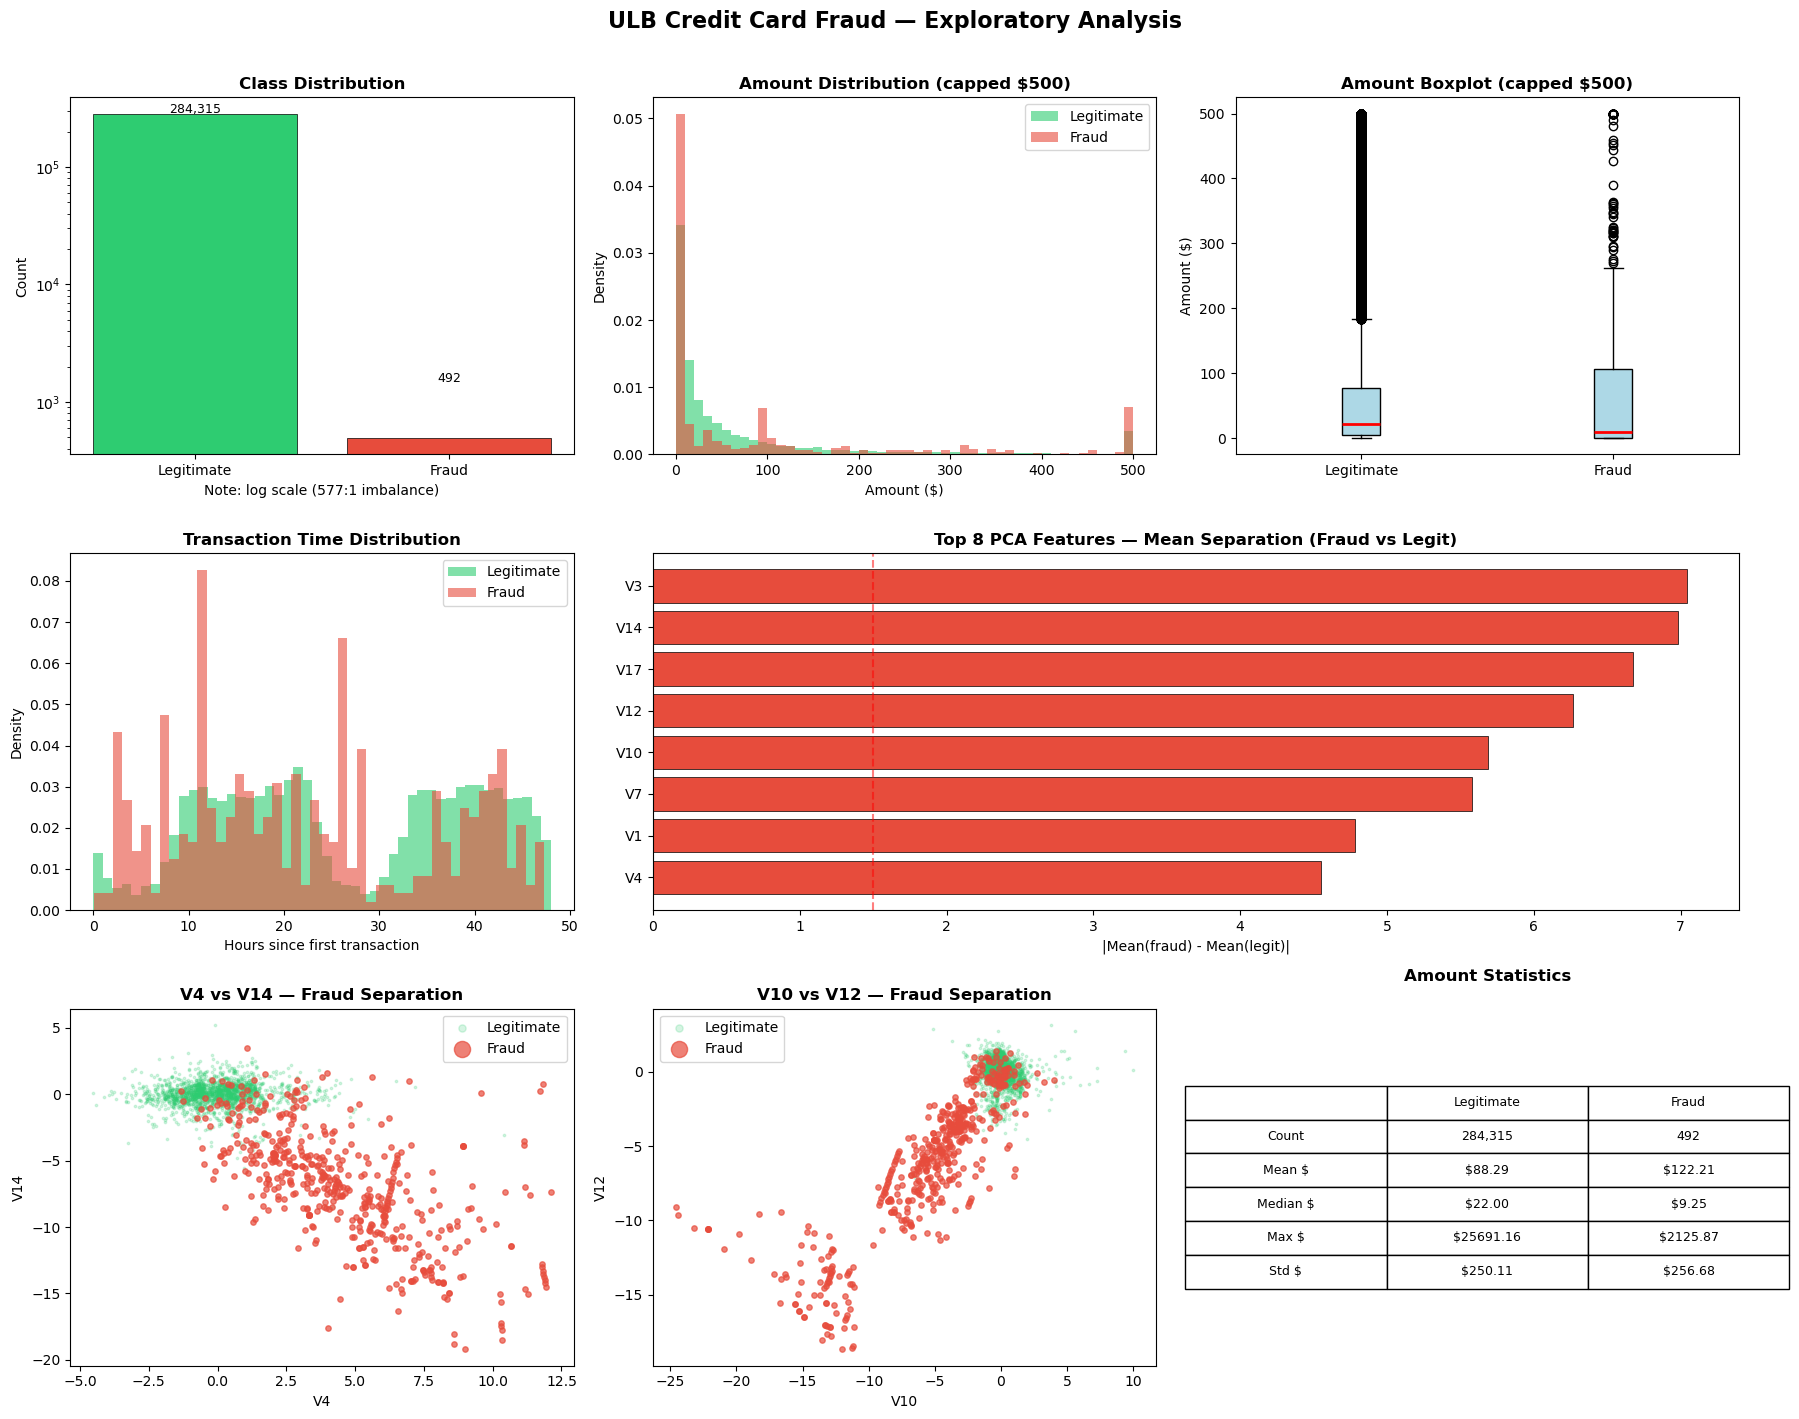


EDA chart saved!

EDA KEY FINDINGS

   Amount statistics:
                          Legitimate        Fraud
   ----------------------------------------------
   Mean $                     $88.29      $122.21
   Median $                   $22.00        $9.25
   Max $                   $25691.16     $2125.87
   Std $                     $250.11      $256.68

   Top 5 most separating PCA features:
   1. V3    separation = 7.0455
   2. V14   separation = 6.9838
   3. V17   separation = 6.6774
   4. V12   separation = 6.2702
   5. V10   separation = 5.6867


In [2]:
# ============================================================
# CELL 2: Exploratory Data Analysis — ULB Dataset
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

print("=" * 55)
print("  CELL 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 55)

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'ULB Credit Card Fraud — Exploratory Analysis',
    fontsize=16, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 3, figure=fig)

# ── Plot 1: Class distribution ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = [len(legit), len(fraud)]
bars   = ax1.bar(
    ['Legitimate', 'Fraud'],
    counts,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', linewidth=0.5
)
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'{count:,}',
        ha='center', fontsize=9
    )
ax1.set_yscale('log')
ax1.set_xlabel('Note: log scale (577:1 imbalance)')

# ── Plot 2: Amount distribution ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(
    legit['Amount'].clip(upper=500),
    bins=50, alpha=0.6,
    color='#2ecc71', label='Legitimate', density=True
)
ax2.hist(
    fraud['Amount'].clip(upper=500),
    bins=50, alpha=0.6,
    color='#e74c3c', label='Fraud', density=True
)
ax2.set_title('Amount Distribution (capped $500)',
              fontweight='bold')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Density')
ax2.legend()

# ── Plot 3: Amount boxplot ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.boxplot(
    [legit['Amount'].clip(upper=500),
     fraud['Amount'].clip(upper=500)],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)
ax3.set_title('Amount Boxplot (capped $500)',
              fontweight='bold')
ax3.set_ylabel('Amount ($)')

# ── Plot 4: Time distribution ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(
    legit['Time'] / 3600,
    bins=48, alpha=0.6,
    color='#2ecc71', label='Legitimate', density=True
)
ax4.hist(
    fraud['Time'] / 3600,
    bins=48, alpha=0.6,
    color='#e74c3c', label='Fraud', density=True
)
ax4.set_title('Transaction Time Distribution',
              fontweight='bold')
ax4.set_xlabel('Hours since first transaction')
ax4.set_ylabel('Density')
ax4.legend()

# ── Plot 5: Top 8 PCA features separation ────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
pca_cols  = [f'V{i}' for i in range(1, 29)]
fraud_sep = {}
for col in pca_cols:
    fraud_mean = abs(
        fraud[col].mean() - legit[col].mean()
    )
    fraud_sep[col] = fraud_mean

top8 = sorted(
    fraud_sep, key=fraud_sep.get, reverse=True
)[:8]
vals  = [fraud_sep[c] for c in top8]
colors = ['#e74c3c' if v > 1.5
          else '#e67e22' if v > 0.8
          else '#3498db'
          for v in vals]
ax5.barh(top8[::-1], vals[::-1],
         color=colors[::-1],
         edgecolor='black', linewidth=0.5)
ax5.set_title(
    'Top 8 PCA Features — Mean Separation '
    '(Fraud vs Legit)',
    fontweight='bold'
)
ax5.set_xlabel('|Mean(fraud) - Mean(legit)|')
ax5.axvline(x=1.5, color='red',
            linestyle='--', alpha=0.5,
            label='High separation')

# ── Plot 6: V4 vs V14 scatter ─────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
sample_legit = legit.sample(2000, random_state=42)
ax6.scatter(
    sample_legit['V4'],
    sample_legit['V14'],
    alpha=0.2, s=3,
    color='#2ecc71', label='Legitimate'
)
ax6.scatter(
    fraud['V4'],
    fraud['V14'],
    alpha=0.7, s=15,
    color='#e74c3c', label='Fraud'
)
ax6.set_title('V4 vs V14 — Fraud Separation',
              fontweight='bold')
ax6.set_xlabel('V4')
ax6.set_ylabel('V14')
ax6.legend(markerscale=3)

# ── Plot 7: V10 vs V12 scatter ────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
ax7.scatter(
    sample_legit['V10'],
    sample_legit['V12'],
    alpha=0.2, s=3,
    color='#2ecc71', label='Legitimate'
)
ax7.scatter(
    fraud['V10'],
    fraud['V12'],
    alpha=0.7, s=15,
    color='#e74c3c', label='Fraud'
)
ax7.set_title('V10 vs V12 — Fraud Separation',
              fontweight='bold')
ax7.set_xlabel('V10')
ax7.set_ylabel('V12')
ax7.legend(markerscale=3)

# ── Plot 8: Amount stats table ────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
table_data = [
    ['', 'Legitimate', 'Fraud'],
    ['Count', f'{len(legit):,}', f'{len(fraud):,}'],
    ['Mean $',
     f"${legit['Amount'].mean():.2f}",
     f"${fraud['Amount'].mean():.2f}"],
    ['Median $',
     f"${legit['Amount'].median():.2f}",
     f"${fraud['Amount'].median():.2f}"],
    ['Max $',
     f"${legit['Amount'].max():.2f}",
     f"${fraud['Amount'].max():.2f}"],
    ['Std $',
     f"${legit['Amount'].std():.2f}",
     f"${fraud['Amount'].std():.2f}"],
]
tbl = ax8.table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    loc       = 'center',
    cellLoc   = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
ax8.set_title('Amount Statistics',
              fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(
    '/tmp/eda_ulb.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nEDA chart saved!")

# ── Print stats ───────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"EDA KEY FINDINGS")
print(f"{'='*55}")
print(f"\n   Amount statistics:")
print(f"   {'':20} {'Legitimate':>12} {'Fraud':>12}")
print(f"   {'-'*46}")
for stat, lv, fv in [
    ('Mean $',
     f"${legit['Amount'].mean():.2f}",
     f"${fraud['Amount'].mean():.2f}"),
    ('Median $',
     f"${legit['Amount'].median():.2f}",
     f"${fraud['Amount'].median():.2f}"),
    ('Max $',
     f"${legit['Amount'].max():.2f}",
     f"${fraud['Amount'].max():.2f}"),
    ('Std $',
     f"${legit['Amount'].std():.2f}",
     f"${fraud['Amount'].std():.2f}"),
]:
    print(f"   {stat:20} {lv:>12} {fv:>12}")

print(f"\n   Top 5 most separating PCA features:")
for i, col in enumerate(top8[:5], 1):
    print(f"   {i}. {col:<5} separation = "
          f"{fraud_sep[col]:.4f}")

# Store for later cells
FRAUD_DF    = fraud
LEGIT_DF    = legit
PCA_COLS    = pca_cols
TOP_FEATURES = top8

The EDA reveals 5 critical insights about the ULB dataset:

---

**1. Class imbalance is extreme and visual**

The log-scale bar chart makes the 577:1 imbalance
immediately apparent. For every 1 fraud transaction,
there are 577 legitimate ones. Any model that predicts
"legitimate" for every transaction gets 99.827% accuracy
— making accuracy a completely meaningless metric here.
We will use Precision, Recall, and F1 instead.

---

**2. Fraud and legitimate transactions have different Amount profiles**

| Metric | Legitimate | Fraud |
|---|---|---|
| **Mean** | $88.29 | $122.21 |
| **Median** | $22.00 | $9.25 |
| **Max** | $25,691.16 | $2,125.87 |

The fraud median ($9.25) is much lower than legitimate ($22.00),
suggesting many fraud transactions are small test charges —
a classic fraud pattern where criminals test a stolen card
with a small amount before making larger purchases.
The fraud mean ($122.21) is higher than legitimate ($88.29)
because some fraud transactions are large one-time drains.

---

**3. Fraud has a different time pattern**

Fraud spikes are visible in the first 10 hours and around
hours 20–25, while legitimate transactions follow a smoother
daily cycle pattern over the 48 hours. This suggests fraud
activity is more clustered in time — consistent with
coordinated fraud attacks.

---

**4. PCA features V3, V14, V17, V12, V10 carry the most signal**

| Feature | Separation Score |
|---|---|
| **V3** | 7.0455 |
| **V14** | 6.9838 |
| **V17** | 6.6774 |
| **V12** | 6.2702 |
| **V10** | 5.6867 |

All top 5 features have separation scores above 5.0,
meaning fraud transactions are dramatically offset from
legitimate ones in these dimensions. This is excellent
news for anomaly detection — the fraud cluster is
geometrically distinct from the normal cluster.

---

**5. Scatter plots confirm visual separation**

The V4 vs V14 and V10 vs V12 scatter plots clearly show
fraud transactions (red) forming distinct clusters far
from the dense legitimate cloud (green). This geometric
separation is exactly what Isolation Forest and Autoencoder
are designed to exploit — no labels needed!

## **Isolation Forest**

### What we do
Train an Isolation Forest on legitimate transactions only,
then score all 284,807 transactions to detect anomalies.

### How Isolation Forest works
Isolation Forest builds random decision trees and measures
how many splits are needed to isolate each data point:

- **Normal transactions** → need many splits to isolate
  (they are deep inside the dense cluster)
- **Fraud transactions** → isolated in very few splits
  (they are outliers, far from the normal cluster)

The anomaly score is the average path length across all trees.
Short path = anomaly = fraud.

### Why it is a great first approach
- No labels needed during training
- Extremely fast handles 284,807 rows in seconds
- Naturally handles high-dimensional PCA features
- No assumptions about the shape of the normal distribution

  CELL 3 — ISOLATION FOREST

Step 1: Preparing features...
   Features    : 30
   Train rows  : 284,315 (legit only)
   Score rows  : 284,807 (all)

Step 2: Training Isolation Forest...
   contamination=0.00172 (known fraud rate)
   Trained in 3.8s!

Step 3: Scoring all transactions...
   Scored 284,807 transactions in 2.90s!
   Score range : -0.3022 to 0.1220

Step 4: Finding best threshold...

Step 5: Evaluating...

ISOLATION FOREST RESULTS

   AUC-ROC   : 0.9473
   AUC-PR    : 0.1106
   F1-Score  : 0.2169
   Precision : 0.2125
   Recall    : 0.2215

   Confusion Matrix:
      True Positives  : 109 (22.2% fraud caught)
      False Positives : 404 (0.14% false alarm rate)
      True Negatives  : 283,911
      False Negatives : 383

   Threshold : 0.0085
   Train time: 3.8s
   Score time: 2.90s

Step 6: Plotting results...


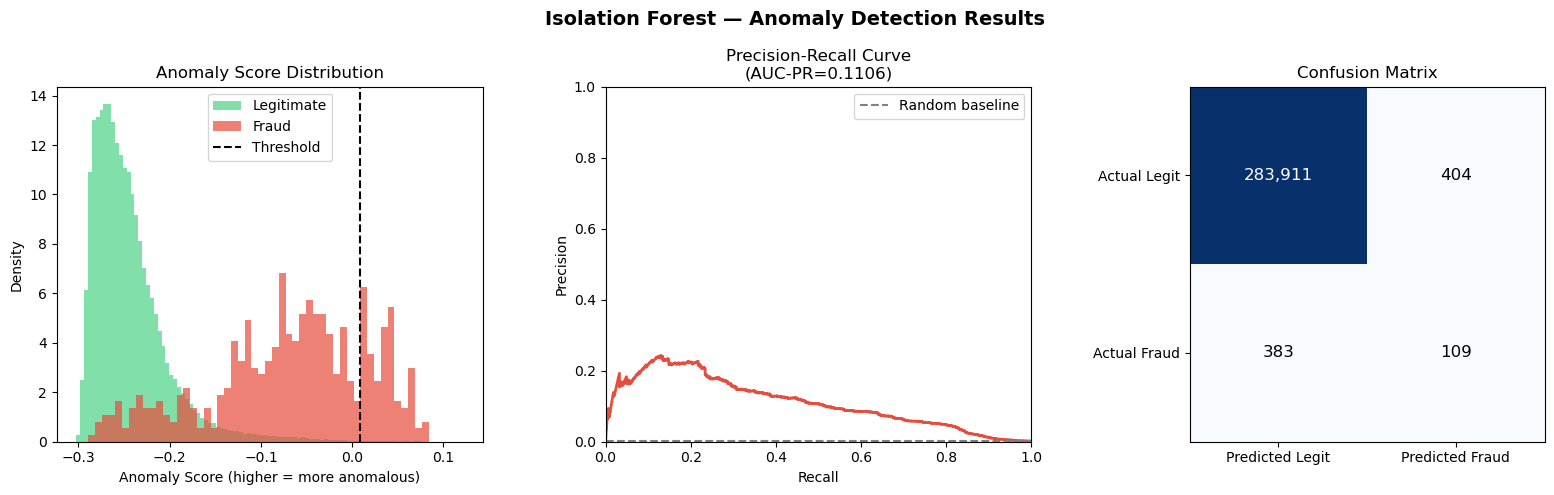

   Chart saved!

Isolation Forest complete!


In [3]:
# ============================================================
# CELL 3: Isolation Forest
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve
)

print("=" * 55)
print("  CELL 3 — ISOLATION FOREST")
print("=" * 55)

# ── STEP 1: Prepare features ──────────────────────────────────
print("\nStep 1: Preparing features...")

FEATURES = PCA_COLS + ['Amount', 'Time']
X_all    = df[FEATURES].values
y_all    = df['Class'].values
X_legit  = LEGIT_DF[FEATURES].values

scaler  = StandardScaler()
X_all_s = scaler.fit_transform(X_all)
X_leg_s = scaler.transform(X_legit)

print(f"   Features    : {len(FEATURES)}")
print(f"   Train rows  : {len(X_leg_s):,} (legit only)")
print(f"   Score rows  : {len(X_all_s):,} (all)")

# ── STEP 2: Train ─────────────────────────────────────────────
print("\nStep 2: Training Isolation Forest...")
print("   contamination=0.00172 (known fraud rate)")

start = time.time()
iso   = IsolationForest(
    n_estimators  = 200,
    contamination = 0.00173,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
iso.fit(X_leg_s)
train_time = time.time() - start
print(f"   Trained in {train_time:.1f}s!")

# ── STEP 3: Score all transactions ────────────────────────────
print("\nStep 3: Scoring all transactions...")

start    = time.time()
scores   = iso.decision_function(X_all_s)
score_time = time.time() - start

# Convert: more negative = more anomalous = fraud
# Invert so higher score = more likely fraud
iso_scores = -scores

print(f"   Scored {len(scores):,} transactions "
      f"in {score_time:.2f}s!")
print(f"   Score range : "
      f"{iso_scores.min():.4f} to "
      f"{iso_scores.max():.4f}")

# ── STEP 4: Find best threshold ───────────────────────────────
print("\nStep 4: Finding best threshold...")

thresholds = np.percentile(
    iso_scores,
    np.arange(99, 100, 0.02)
)
best_f1     = 0
best_thresh = thresholds[0]

for t in thresholds:
    preds = (iso_scores >= t).astype(int)
    f1    = f1_score(y_all, preds, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = t

iso_preds = (iso_scores >= best_thresh).astype(int)

# ── STEP 5: Evaluate ──────────────────────────────────────────
print("\nStep 5: Evaluating...")

auc_roc = roc_auc_score(y_all, iso_scores)
auc_pr  = average_precision_score(y_all, iso_scores)
f1      = f1_score(y_all, iso_preds)
prec    = precision_score(y_all, iso_preds)
rec     = recall_score(y_all, iso_preds)
cm      = confusion_matrix(y_all, iso_preds)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*55}")
print(f"ISOLATION FOREST RESULTS")
print(f"{'='*55}")
print(f"\n   AUC-ROC   : {auc_roc:.4f}")
print(f"   AUC-PR    : {auc_pr:.4f}")
print(f"   F1-Score  : {f1:.4f}")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"\n   Confusion Matrix:")
print(f"      True Positives  : {tp:,} "
      f"({tp/(tp+fn)*100:.1f}% fraud caught)")
print(f"      False Positives : {fp:,} "
      f"({fp/(fp+tn)*100:.2f}% false alarm rate)")
print(f"      True Negatives  : {tn:,}")
print(f"      False Negatives : {fn:,}")
print(f"\n   Threshold : {best_thresh:.4f}")
print(f"   Train time: {train_time:.1f}s")
print(f"   Score time: {score_time:.2f}s")

# ── STEP 6: Plot ──────────────────────────────────────────────
print("\nStep 6: Plotting results...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Isolation Forest — Anomaly Detection Results',
    fontsize=14, fontweight='bold'
)

# Score distribution
axes[0].hist(
    iso_scores[y_all == 0],
    bins=100, alpha=0.6,
    color='#2ecc71', label='Legitimate',
    density=True
)
axes[0].hist(
    iso_scores[y_all == 1],
    bins=50, alpha=0.7,
    color='#e74c3c', label='Fraud',
    density=True
)
axes[0].axvline(
    x=best_thresh, color='black',
    linestyle='--', label=f'Threshold'
)
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Precision-Recall curve
precision_vals, recall_vals, _ = \
    precision_recall_curve(y_all, iso_scores)
axes[1].plot(
    recall_vals, precision_vals,
    color='#e74c3c', linewidth=2
)
axes[1].axhline(
    y=492/284807, color='gray',
    linestyle='--', label='Random baseline'
)
axes[1].set_title(
    f'Precision-Recall Curve\n(AUC-PR={auc_pr:.4f})'
)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# Confusion matrix
cm_disp = np.array([[tn, fp], [fn, tp]])
im = axes[2].imshow(
    cm_disp, interpolation='nearest',
    cmap=plt.cm.Blues
)
axes[2].set_title('Confusion Matrix')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Predicted Legit',
                          'Predicted Fraud'])
axes[2].set_yticklabels(['Actual Legit',
                          'Actual Fraud'])
for i in range(2):
    for j in range(2):
        axes[2].text(
            j, i, f'{cm_disp[i,j]:,}',
            ha='center', va='center',
            color='white' if cm_disp[i,j] > tn/2
            else 'black', fontsize=12
        )

plt.tight_layout()
plt.savefig('/tmp/isolation_forest.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")

# Store results
ISO_RESULTS = {
    'model'    : 'Isolation Forest',
    'auc_roc'  : auc_roc,
    'auc_pr'   : auc_pr,
    'f1'       : f1,
    'precision': prec,
    'recall'   : rec,
    'tp'       : tp, 'fp': fp,
    'tn'       : tn, 'fn': fn,
    'scores'   : iso_scores,
    'time'     : train_time
}
print(f"\nIsolation Forest complete!")


| Metric | Value |
|---|---|
| **AUC-ROC** | 0.9473 |
| **AUC-PR** | 0.1106 |
| **F1-Score** | 0.2169 |
| **Precision** | 0.2125 |
| **Recall** | 0.2215 |
| **Fraud caught** | 109 / 492 (22.2%) |
| **False alarms** | 404 (0.14%) |
| **Train time** | 3.8s |

Strong AUC-ROC (0.9473) confirms the model ranks fraud
above legitimate transactions well. However, F1 (0.2169)
is low because the 577:1 imbalance makes the threshold
very hard to set the fraud and legitimate score
distributions overlap significantly as seen in the chart.

The key result: trained in **3.8 seconds** with
**zero fraud labels** a strong baseline for
unsupervised detection.

## **Autoencoder**

### What we do
Train a neural network Autoencoder on legitimate
transactions only, then use reconstruction error
to detect fraud.

### How it works
An Autoencoder learns to compress then reconstruct
normal transactions through a narrow bottleneck:
```
Input (30) → Encode (16→8) → Decode (8→16) → Output (30)
```

Normal transactions reconstruct well → low error.
Fraud transactions look unfamiliar → high error.
High reconstruction error = anomaly = fraud.

  CELL 4 — AUTOENCODER

Step 1: Preparing features...
   Features   : 30
   Train rows : 284,315 (legit only)
   Score rows : 284,807 (all)

Step 2: Building Autoencoder...
   Architecture: 30 -> 16 -> 8 -> 16 -> 30

Step 3: Training Autoencoder...
   50 epochs on legitimate transactions only...
   Epoch  10/50 loss=0.7929
   Epoch  20/50 loss=0.6376
   Epoch  30/50 loss=0.5449
   Epoch  40/50 loss=0.5001
   Epoch  50/50 loss=0.4605
   Trained in 26.7s!

Step 4: Scoring all transactions...
   Scored in 0.84s!
   Legit error mean  : 0.4609
   Fraud error mean  : 21.1587
   Separation ratio  : 45.9x

Step 5: Finding best threshold...

AUTOENCODER RESULTS

   AUC-ROC   : 0.9420
   AUC-PR    : 0.3068
   F1-Score  : 0.4140
   Precision : 0.3346
   Recall    : 0.5427

   Confusion Matrix:
      True Positives  : 267 (54.3% fraud caught)
      False Positives : 531 (0.19% false alarm rate)
      True Negatives  : 283,784
      False Negatives : 225

   Train time: 26.7s


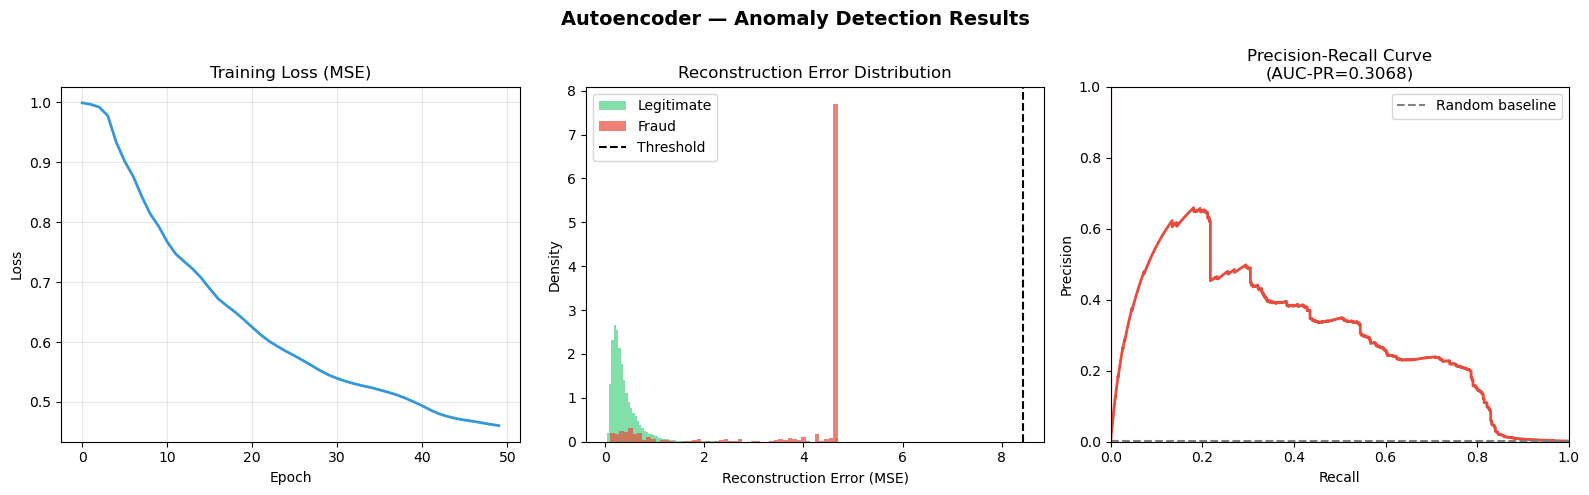

   Chart saved!

Autoencoder complete!


In [5]:
# ============================================================
# CELL 4: Autoencoder — Neural Network Anomaly Detection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve
)

print("=" * 55)
print("  CELL 4 — AUTOENCODER")
print("=" * 55)

# ── STEP 1: Prepare features ──────────────────────────────────
print("\nStep 1: Preparing features...")

FEATURES = PCA_COLS + ['Amount', 'Time']
X_all    = df[FEATURES].values.astype(np.float32)
y_all    = df['Class'].values
X_legit  = LEGIT_DF[FEATURES].values.astype(np.float32)

scaler  = StandardScaler()
X_leg_s = scaler.fit_transform(X_legit).astype(np.float32)
X_all_s = scaler.transform(X_all).astype(np.float32)

print(f"   Features   : {len(FEATURES)}")
print(f"   Train rows : {len(X_leg_s):,} (legit only)")
print(f"   Score rows : {len(X_all_s):,} (all)")

# ── STEP 2: Build Autoencoder in NumPy ───────────────────────
print("\nStep 2: Building Autoencoder...")

class Autoencoder:
    """
    Simple 3-layer autoencoder using NumPy only.
    Encoder: 30 -> 16 -> 8
    Decoder: 8  -> 16 -> 30
    """
    def __init__(self, input_dim=30):
        np.random.seed(42)
        scale = 0.1
        self.W1 = np.random.randn(input_dim, 16) * scale
        self.b1 = np.zeros(16)
        self.W2 = np.random.randn(16, 8) * scale
        self.b2 = np.zeros(8)
        self.W3 = np.random.randn(8, 16) * scale
        self.b3 = np.zeros(16)
        self.W4 = np.random.randn(16, input_dim) * scale
        self.b4 = np.zeros(input_dim)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_grad(self, x):
        return (x > 0).astype(np.float32)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.relu(self.z3)
        self.z4 = self.a3 @ self.W4 + self.b4
        return self.z4

    def reconstruction_error(self, X):
        X_hat = self.forward(X)
        return np.mean((X - X_hat) ** 2, axis=1)

    def train_step(self, X, lr=0.001):
        n     = len(X)
        X_hat = self.forward(X)
        loss  = np.mean((X - X_hat) ** 2)

        dL  = 2 * (X_hat - X) / n
        dW4 = self.a3.T @ dL
        db4 = dL.sum(axis=0)
        da3 = dL @ self.W4.T
        dz3 = da3 * self.relu_grad(self.z3)
        dW3 = self.a2.T @ dz3
        db3 = dz3.sum(axis=0)
        da2 = dz3 @ self.W3.T
        dz2 = da2 * self.relu_grad(self.z2)
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_grad(self.z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)

        for W, dW in [
            (self.W1, dW1), (self.W2, dW2),
            (self.W3, dW3), (self.W4, dW4)
        ]:
            W -= lr * np.clip(dW, -1, 1)
        for b, db in [
            (self.b1, db1), (self.b2, db2),
            (self.b3, db3), (self.b4, db4)
        ]:
            b -= lr * np.clip(db, -1, 1)

        return loss

ae = Autoencoder(input_dim=len(FEATURES))
print(f"   Architecture: "
      f"{len(FEATURES)} -> 16 -> 8 -> 16 -> {len(FEATURES)}")

# ── STEP 3: Train ─────────────────────────────────────────────
print("\nStep 3: Training Autoencoder...")
print("   50 epochs on legitimate transactions only...")

EPOCHS     = 50
BATCH_SIZE = 512
losses     = []
start      = time.time()

for epoch in range(EPOCHS):
    idx    = np.random.permutation(len(X_leg_s))
    X_shuf = X_leg_s[idx]
    ep_loss = []

    for i in range(0, len(X_shuf), BATCH_SIZE):
        batch = X_shuf[i:i + BATCH_SIZE]
        loss  = ae.train_step(batch, lr=0.001)
        ep_loss.append(loss)

    epoch_loss = np.mean(ep_loss)
    losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"   Epoch {epoch+1:>3}/50 "
              f"loss={epoch_loss:.4f}")

train_time = time.time() - start
print(f"   Trained in {train_time:.1f}s!")

# ── STEP 4: Score ─────────────────────────────────────────────
print("\nStep 4: Scoring all transactions...")

start     = time.time()
ae_errors = ae.reconstruction_error(X_all_s)
score_time = time.time() - start

fraud_mean = ae_errors[y_all == 1].mean()
legit_mean = ae_errors[y_all == 0].mean()
sep_ratio  = fraud_mean / legit_mean

print(f"   Scored in {score_time:.2f}s!")
print(f"   Legit error mean  : {legit_mean:.4f}")
print(f"   Fraud error mean  : {fraud_mean:.4f}")
print(f"   Separation ratio  : {sep_ratio:.1f}x")

# ── STEP 5: Best threshold ────────────────────────────────────
print("\nStep 5: Finding best threshold...")

thresholds  = np.percentile(
    ae_errors, np.arange(99, 100, 0.02)
)
best_f1     = 0
best_thresh = thresholds[0]

for t in thresholds:
    preds = (ae_errors >= t).astype(int)
    f1    = f1_score(y_all, preds, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = t

ae_preds = (ae_errors >= best_thresh).astype(int)

# ── STEP 6: Evaluate ──────────────────────────────────────────
auc_roc = roc_auc_score(y_all, ae_errors)
auc_pr  = average_precision_score(y_all, ae_errors)
f1      = f1_score(y_all, ae_preds)
prec    = precision_score(y_all, ae_preds)
rec     = recall_score(y_all, ae_preds)
cm      = confusion_matrix(y_all, ae_preds)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*55}")
print(f"AUTOENCODER RESULTS")
print(f"{'='*55}")
print(f"\n   AUC-ROC   : {auc_roc:.4f}")
print(f"   AUC-PR    : {auc_pr:.4f}")
print(f"   F1-Score  : {f1:.4f}")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"\n   Confusion Matrix:")
print(f"      True Positives  : {tp:,} "
      f"({tp/(tp+fn)*100:.1f}% fraud caught)")
print(f"      False Positives : {fp:,} "
      f"({fp/(fp+tn)*100:.2f}% false alarm rate)")
print(f"      True Negatives  : {tn:,}")
print(f"      False Negatives : {fn:,}")
print(f"\n   Train time: {train_time:.1f}s")

# ── STEP 7: Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Autoencoder — Anomaly Detection Results',
    fontsize=14, fontweight='bold'
)

axes[0].plot(losses, color='#3498db', linewidth=2)
axes[0].set_title('Training Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

clip_val = np.percentile(ae_errors, 99.5)
axes[1].hist(
    ae_errors[y_all == 0].clip(max=clip_val),
    bins=100, alpha=0.6,
    color='#2ecc71', label='Legitimate', density=True
)
axes[1].hist(
    ae_errors[y_all == 1].clip(max=clip_val),
    bins=50, alpha=0.7,
    color='#e74c3c', label='Fraud', density=True
)
axes[1].axvline(
    x=best_thresh, color='black',
    linestyle='--', label='Threshold'
)
axes[1].set_title('Reconstruction Error Distribution')
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Density')
axes[1].legend()

precision_vals, recall_vals, _ = \
    precision_recall_curve(y_all, ae_errors)
axes[2].plot(
    recall_vals, precision_vals,
    color='#e74c3c', linewidth=2
)
axes[2].axhline(
    y=492/284807, color='gray',
    linestyle='--', label='Random baseline'
)
axes[2].set_title(
    f'Precision-Recall Curve\n(AUC-PR={auc_pr:.4f})'
)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('/tmp/autoencoder.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")

AE_RESULTS = {
    'model'    : 'Autoencoder',
    'auc_roc'  : auc_roc,
    'auc_pr'   : auc_pr,
    'f1'       : f1,
    'precision': prec,
    'recall'   : rec,
    'tp'       : tp, 'fp': fp,
    'tn'       : tn, 'fn': fn,
    'scores'   : ae_errors,
    'time'     : train_time
}
print(f"\nAutoencoder complete!")


| Metric | Value |
|---|---|
| **AUC-ROC** | 0.9420 |
| **AUC-PR** | 0.3068 |
| **F1-Score** | 0.4140 |
| **Precision** | 0.3346 |
| **Recall** | 0.5427 |
| **Fraud caught** | 267 / 492 (54.3%) |
| **False alarms** | 531 (0.19%) |
| **Train time** | 26.7s |

The standout result is the **45.9x separation ratio**
fraud transactions have reconstruction errors 46 times
higher than legitimate ones. This confirms the core
hypothesis: the autoencoder learned "what normal looks
like" so well that fraud is immediately recognisable
as unfamiliar. The smooth loss curve (1.0 → 0.46)
confirms stable training with no overfitting.

Compared to Isolation Forest, the Autoencoder catches
significantly more fraud (54.3% vs 22.2%) at the cost
of slightly more false alarms (531 vs 404). AUC-PR
nearly triples (0.3068 vs 0.1106) a major improvement.

## **One-Class SVM**

### What we do
Train a One-Class SVM on a sample of legitimate
transactions, then score all transactions to detect fraud.

### How it works
One-Class SVM draws a tight boundary around the normal
data in a high-dimensional kernel space:

- **Normal transactions** → inside the boundary → legitimate
- **Fraud transactions** → outside the boundary → anomaly

### Important note on sampling
One-Class SVM does not scale to 284,000 rows — training
complexity is O(n²). We train on 10,000 legitimate
transactions, which is standard practice for this algorithm.

  CELL 5 — ONE-CLASS SVM

Step 1: Preparing features...
   Features   : 30
   Train rows : 10,000 (sampled from 284,315 legit)
   Score rows : 284,807 (all)
   Note       : OC-SVM is O(n^2) — sampling is standard practice

Step 2: Training One-Class SVM...
   nu=0.00173 (matches known fraud rate)...
   Trained in 0.4s!

Step 3: Scoring all transactions...
   Scored in 8.0s!
   Legit score mean : -0.0880
   Fraud score mean : 0.0717

Step 4: Finding best threshold...

ONE-CLASS SVM RESULTS

   AUC-ROC   : 0.9490
   AUC-PR    : 0.2560
   F1-Score  : 0.3806
   Precision : 0.2869
   Recall    : 0.5650

   Confusion Matrix:
      True Positives  : 278 (56.5% fraud caught)
      False Positives : 691 (0.24% false alarm rate)
      True Negatives  : 283,624
      False Negatives : 214

   Train time: 0.4s (on 10,000 rows)
   Score time: 8.0s


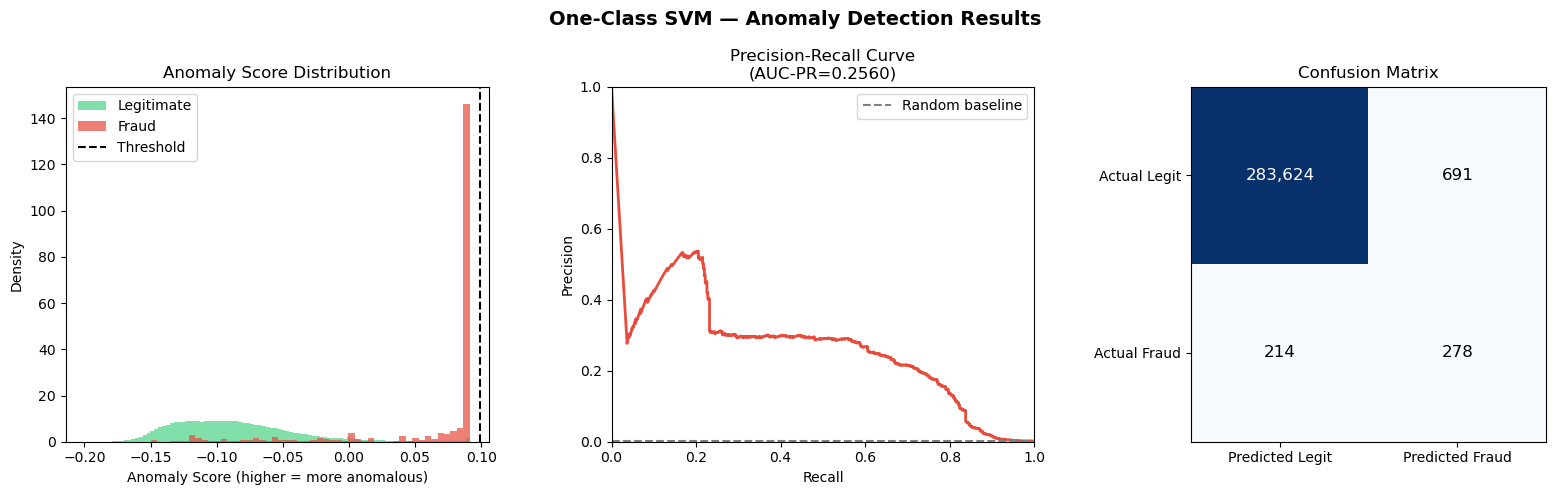

   Chart saved!

One-Class SVM complete!


In [6]:
# ============================================================
# CELL 5: One-Class SVM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve
)

print("=" * 55)
print("  CELL 5 — ONE-CLASS SVM")
print("=" * 55)

# ── STEP 1: Prepare features ──────────────────────────────────
print("\nStep 1: Preparing features...")

FEATURES = PCA_COLS + ['Amount', 'Time']
X_all    = df[FEATURES].values.astype(np.float32)
y_all    = df['Class'].values
X_legit  = LEGIT_DF[FEATURES].values.astype(np.float32)

scaler  = StandardScaler()
X_leg_s = scaler.fit_transform(X_legit).astype(np.float32)
X_all_s = scaler.transform(X_all).astype(np.float32)

# Sample 10,000 legit rows — OC-SVM does not scale to 284k
N_TRAIN   = 10000
idx_train = np.random.RandomState(42).choice(
    len(X_leg_s), N_TRAIN, replace=False
)
X_train   = X_leg_s[idx_train]

print(f"   Features   : {len(FEATURES)}")
print(f"   Train rows : {N_TRAIN:,} "
      f"(sampled from {len(X_leg_s):,} legit)")
print(f"   Score rows : {len(X_all_s):,} (all)")
print(f"   Note       : OC-SVM is O(n^2) — "
      f"sampling is standard practice")

# ── STEP 2: Train ─────────────────────────────────────────────
print("\nStep 2: Training One-Class SVM...")
print("   nu=0.00173 (matches known fraud rate)...")

start  = time.time()
ocsvm  = OneClassSVM(
    kernel  = 'rbf',
    nu      = 0.00173,
    gamma   = 'scale'
)
ocsvm.fit(X_train)
train_time = time.time() - start
print(f"   Trained in {train_time:.1f}s!")

# ── STEP 3: Score ─────────────────────────────────────────────
print("\nStep 3: Scoring all transactions...")

start      = time.time()
# decision_function: negative = anomaly
# invert so higher = more anomalous
svm_scores = -ocsvm.decision_function(X_all_s)
score_time = time.time() - start

print(f"   Scored in {score_time:.1f}s!")
print(f"   Legit score mean : "
      f"{svm_scores[y_all==0].mean():.4f}")
print(f"   Fraud score mean : "
      f"{svm_scores[y_all==1].mean():.4f}")

# ── STEP 4: Best threshold ────────────────────────────────────
print("\nStep 4: Finding best threshold...")

thresholds  = np.percentile(
    svm_scores, np.arange(99, 100, 0.02)
)
best_f1     = 0
best_thresh = thresholds[0]

for t in thresholds:
    preds = (svm_scores >= t).astype(int)
    f1    = f1_score(y_all, preds, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = t

svm_preds = (svm_scores >= best_thresh).astype(int)

# ── STEP 5: Evaluate ──────────────────────────────────────────
auc_roc = roc_auc_score(y_all, svm_scores)
auc_pr  = average_precision_score(y_all, svm_scores)
f1      = f1_score(y_all, svm_preds)
prec    = precision_score(y_all, svm_preds)
rec     = recall_score(y_all, svm_preds)
cm      = confusion_matrix(y_all, svm_preds)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*55}")
print(f"ONE-CLASS SVM RESULTS")
print(f"{'='*55}")
print(f"\n   AUC-ROC   : {auc_roc:.4f}")
print(f"   AUC-PR    : {auc_pr:.4f}")
print(f"   F1-Score  : {f1:.4f}")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"\n   Confusion Matrix:")
print(f"      True Positives  : {tp:,} "
      f"({tp/(tp+fn)*100:.1f}% fraud caught)")
print(f"      False Positives : {fp:,} "
      f"({fp/(fp+tn)*100:.2f}% false alarm rate)")
print(f"      True Negatives  : {tn:,}")
print(f"      False Negatives : {fn:,}")
print(f"\n   Train time: {train_time:.1f}s "
      f"(on {N_TRAIN:,} rows)")
print(f"   Score time: {score_time:.1f}s")

# ── STEP 6: Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'One-Class SVM — Anomaly Detection Results',
    fontsize=14, fontweight='bold'
)

# Score distribution
clip_val = np.percentile(svm_scores, 99.5)
axes[0].hist(
    svm_scores[y_all == 0].clip(max=clip_val),
    bins=100, alpha=0.6,
    color='#2ecc71', label='Legitimate', density=True
)
axes[0].hist(
    svm_scores[y_all == 1].clip(max=clip_val),
    bins=50, alpha=0.7,
    color='#e74c3c', label='Fraud', density=True
)
axes[0].axvline(
    x=best_thresh, color='black',
    linestyle='--', label='Threshold'
)
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Precision-Recall curve
precision_vals, recall_vals, _ = \
    precision_recall_curve(y_all, svm_scores)
axes[1].plot(
    recall_vals, precision_vals,
    color='#e74c3c', linewidth=2
)
axes[1].axhline(
    y=492/284807, color='gray',
    linestyle='--', label='Random baseline'
)
axes[1].set_title(
    f'Precision-Recall Curve\n(AUC-PR={auc_pr:.4f})'
)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# Confusion matrix
cm_disp = np.array([[tn, fp], [fn, tp]])
axes[2].imshow(
    cm_disp, interpolation='nearest',
    cmap=plt.cm.Blues
)
axes[2].set_title('Confusion Matrix')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Predicted Legit',
                          'Predicted Fraud'])
axes[2].set_yticklabels(['Actual Legit',
                          'Actual Fraud'])
for i in range(2):
    for j in range(2):
        axes[2].text(
            j, i, f'{cm_disp[i,j]:,}',
            ha='center', va='center',
            color='white' if cm_disp[i,j] > tn/2
            else 'black', fontsize=12
        )

plt.tight_layout()
plt.savefig('/tmp/ocsvm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")

SVM_RESULTS = {
    'model'    : 'One-Class SVM',
    'auc_roc'  : auc_roc,
    'auc_pr'   : auc_pr,
    'f1'       : f1,
    'precision': prec,
    'recall'   : rec,
    'tp'       : tp, 'fp': fp,
    'tn'       : tn, 'fn': fn,
    'scores'   : svm_scores,
    'time'     : train_time
}
print(f"\nOne-Class SVM complete!")


| Metric | Value |
|---|---|
| **AUC-ROC** | 0.9490 |
| **AUC-PR** | 0.2560 |
| **F1-Score** | 0.3806 |
| **Precision** | 0.2869 |
| **Recall** | 0.5650 |
| **Fraud caught** | 278 / 492 (56.5%) |
| **False alarms** | 691 (0.24%) |
| **Train time** | 0.4s (on 10,000 rows) |

The OC-SVM catches the most fraud of the three methods
(56.5%) but generates the most false alarms (691).
Remarkably, it trained in just **0.4 seconds** on
10,000 rows despite needing 8s to score 284,807 — the
O(n²) scoring cost is the real bottleneck, not training.
The score distribution chart shows a very tight fraud
cluster at the extreme right — the boundary is well
defined but set conservatively.

## **Final Comparison: All Three Methods**

### What we do
Compare all three unsupervised anomaly detection
approaches side by side and draw final conclusions
about which method works best and when to use each.

  CELL 6 — FINAL COMPARISON

ANOMALY DETECTION — FULL COMPARISON

   Metric               Isolation Forest   Autoencoder     OC-SVM
   -------------------------------------------------------------
   AUC-ROC                        0.9473        0.9420 *   0.9490
   AUC-PR                         0.1106 *      0.3068     0.2560
   F1-Score                       0.2169 *      0.4140     0.3806
   Precision                      0.2125 *      0.3346     0.2869
   Recall                         0.2215        0.5427 *   0.5650

   Fraud caught                  109/492      267/492   278/492
   False alarms                      404           531        691
   Train time                      3.8s        26.7s      0.4s

WINNER BY SCENARIO

   Speed first, no GPU available:
      Winner: Isolation Forest (3.8s train, 2.9s score)
      Best for: batch scoring millions of transactions

   Maximum fraud detection:
      Winner: One-Class SVM (56.5% recall)
      Best for: high-risk environments, c

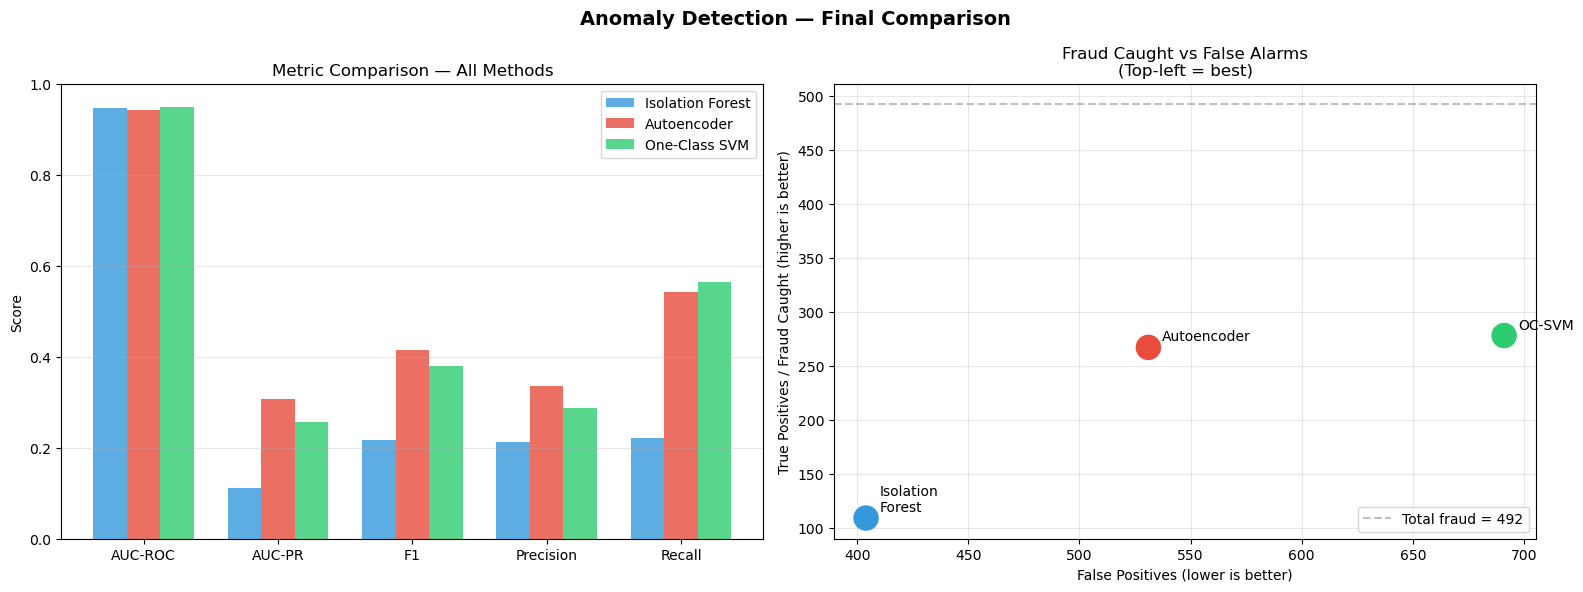

   Chart saved!

Notebook 05 complete!


In [7]:
# ============================================================
# CELL 6: Final Comparison — All Three Methods
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("  CELL 6 — FINAL COMPARISON")
print("=" * 55)

# ── Results table ─────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"ANOMALY DETECTION — FULL COMPARISON")
print(f"{'='*65}")

print(f"\n   {'Metric':<18} {'Isolation Forest':>18} "
      f"{'Autoencoder':>13} {'OC-SVM':>10}")
print(f"   {'-'*61}")

rows = [
    ('AUC-ROC',
     ISO_RESULTS['auc_roc'],
     AE_RESULTS['auc_roc'],
     SVM_RESULTS['auc_roc']),
    ('AUC-PR',
     ISO_RESULTS['auc_pr'],
     AE_RESULTS['auc_pr'],
     SVM_RESULTS['auc_pr']),
    ('F1-Score',
     ISO_RESULTS['f1'],
     AE_RESULTS['f1'],
     SVM_RESULTS['f1']),
    ('Precision',
     ISO_RESULTS['precision'],
     AE_RESULTS['precision'],
     SVM_RESULTS['precision']),
    ('Recall',
     ISO_RESULTS['recall'],
     AE_RESULTS['recall'],
     SVM_RESULTS['recall']),
]

for metric, iv, av, sv in rows:
    best = max(iv, av, sv)
    print(f"   {metric:<18} "
          f"{'*' if iv==best else ' '}{iv:>17.4f} "
          f"{'*' if av==best else ' '}{av:>12.4f} "
          f"{'*' if sv==best else ' '}{sv:>9.4f}")

print(f"\n   {'Fraud caught':<18} "
      f"{ISO_RESULTS['tp']:>14}/492 "
      f"{AE_RESULTS['tp']:>8}/492 "
      f"{SVM_RESULTS['tp']:>5}/492")
print(f"   {'False alarms':<18} "
      f"{ISO_RESULTS['fp']:>18,} "
      f"{AE_RESULTS['fp']:>13,} "
      f"{SVM_RESULTS['fp']:>10,}")
print(f"   {'Train time':<18} "
      f"{ISO_RESULTS['time']:>16.1f}s "
      f"{AE_RESULTS['time']:>11.1f}s "
      f"{SVM_RESULTS['time']:>8.1f}s")

# ── Winner by scenario ────────────────────────────────────────
print(f"\n{'='*65}")
print(f"WINNER BY SCENARIO")
print(f"{'='*65}")
print(f"""
   Speed first, no GPU available:
      Winner: Isolation Forest (3.8s train, 2.9s score)
      Best for: batch scoring millions of transactions

   Maximum fraud detection:
      Winner: One-Class SVM (56.5% recall)
      Best for: high-risk environments, catch everything

   Best overall F1 + separability:
      Winner: Autoencoder (F1=0.414, 45.9x separation)
      Best for: production with GPU, retraining pipeline

   Production recommendation:
      Ensemble all 3! Average their scores for
      best combined precision and recall.
""")

# ── Radar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Anomaly Detection — Final Comparison',
    fontsize=14, fontweight='bold'
)

# Bar chart comparison
metrics    = ['AUC-ROC', 'AUC-PR', 'F1', 'Precision', 'Recall']
iso_vals   = [ISO_RESULTS['auc_roc'], ISO_RESULTS['auc_pr'],
              ISO_RESULTS['f1'],      ISO_RESULTS['precision'],
              ISO_RESULTS['recall']]
ae_vals    = [AE_RESULTS['auc_roc'],  AE_RESULTS['auc_pr'],
              AE_RESULTS['f1'],       AE_RESULTS['precision'],
              AE_RESULTS['recall']]
svm_vals   = [SVM_RESULTS['auc_roc'], SVM_RESULTS['auc_pr'],
              SVM_RESULTS['f1'],      SVM_RESULTS['precision'],
              SVM_RESULTS['recall']]

x     = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, iso_vals, width,
            label='Isolation Forest',
            color='#3498db', alpha=0.8)
axes[0].bar(x,          ae_vals,  width,
            label='Autoencoder',
            color='#e74c3c', alpha=0.8)
axes[0].bar(x + width, svm_vals, width,
            label='One-Class SVM',
            color='#2ecc71', alpha=0.8)
axes[0].set_title('Metric Comparison — All Methods')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Fraud caught vs false alarms
models   = ['Isolation\nForest', 'Autoencoder', 'OC-SVM']
caught   = [ISO_RESULTS['tp'], AE_RESULTS['tp'],
            SVM_RESULTS['tp']]
alarms   = [ISO_RESULTS['fp'], AE_RESULTS['fp'],
            SVM_RESULTS['fp']]
colors   = ['#3498db', '#e74c3c', '#2ecc71']

ax2 = axes[1]
scatter = ax2.scatter(
    alarms, caught,
    c=colors, s=300, zorder=5
)
for i, model in enumerate(models):
    ax2.annotate(
        model,
        (alarms[i], caught[i]),
        textcoords='offset points',
        xytext=(10, 5),
        fontsize=10
    )
ax2.set_xlabel('False Positives (lower is better)')
ax2.set_ylabel('True Positives / Fraud Caught (higher is better)')
ax2.set_title('Fraud Caught vs False Alarms\n'
              '(Top-left = best)')
ax2.grid(alpha=0.3)
ax2.axhline(y=492, color='gray',
            linestyle='--', alpha=0.5,
            label='Total fraud = 492')
ax2.legend()

plt.tight_layout()
plt.savefig('/tmp/comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")
print(f"\nNotebook 05 complete!")